# Regular Season Model Selection

This notebook:
1. Loads regular season game data
2. Calculates point-in-time efficiency ratings (using only past games)
3. Tests multiple model algorithms with hyperparameter tuning
4. Compares performance to identify the best model(s)

## Setup

In [1]:
import pandas as pd
import numpy as np
import sys
sys.path.append('../kaggle_prediction_library/')
import preprocess
import feature_engineering
from rest_sos_features import add_rest_sos_features

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score, accuracy_score
from sklearn.isotonic import IsotonicRegression



import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

In [2]:
regular_season_results = pd.read_csv('../data/MRegularSeasonDetailedResults.csv')
detailed_tourney_results = pd.read_csv('../data/MNCAATourneyDetailedResults.csv')
rankings = pd.read_csv('../data/MMasseyOrdinals.csv')
seeds = pd.read_csv('../data/MNCAATourneySeeds.csv')

# kp_rankings = pd.read_csv('../data/kenpom_pre_tourney_snapshot.csv')

regular_season_results_w = pd.read_csv('../data/WRegularSeasonDetailedResults.csv')
detailed_tourney_results_w = pd.read_csv('../data/WNCAATourneyDetailedResults.csv')

mteams = pd.read_csv('../data/MTeams.csv')
wteams = pd.read_csv('../data/WTeams.csv')

seeds_w = pd.read_csv('../data/WNCAATourneySeeds.csv')

# M538 = pd.read_csv('../data/M538.csv')
# W538 = pd.read_csv('../data/W538.csv')

seed_round = pd.read_csv("../data/MNCAATourneySeedRoundSlots.csv")
seeds = pd.read_csv("../data/MNCAATourneySeeds.csv")

first_round_odds_data = pd.read_csv('../data/sky_data/first_round_odds_ncaam.csv')
first_round_odds_data_w = pd.read_csv('../data/sky_data/first_round_odds_ncaaw.csv')

sub_df = pd.read_csv("SampleSubmission2024.csv")

# Use the preprocess module to get unified format
_, _, regular_season_games, _ = preprocess.full_setup(
    detailed_tourney_results, 
    regular_season_results,
    detailed_tourney_results_w, 
    regular_season_results_w,
    sub_df, 
    mteams
)

print(f"\nProcessed games shape: {regular_season_games.shape}")
print(f"Columns: {list(regular_season_games.columns)}")
print(f"\nSample:")
display(regular_season_games.head(3))



Processed games shape: (237764, 38)
Columns: ['TourneyGame', 'Season', 'DayNum', 'Team1', 'Team2', 'Team1_score', 'Team2_score', 'WLoc', 'NumOT', 'Team1_FGM', 'Team1_FGA', 'Team1_FGM3', 'Team1_FGA3', 'Team1_FTM', 'Team1_FTA', 'Team1_OR', 'Team1_DR', 'Team1_Ast', 'Team1_TO', 'Team1_Stl', 'Team1_Blk', 'Team1_PF', 'Team2_FGM', 'Team2_FGA', 'Team2_FGM3', 'Team2_FGA3', 'Team2_FTM', 'Team2_FTA', 'Team2_OR', 'Team2_DR', 'Team2_Ast', 'Team2_TO', 'Team2_Stl', 'Team2_Blk', 'Team2_PF', 'Outcome', 'Loc', 'margin']

Sample:


,TourneyGame,Season,DayNum,Team1,Team2,Team1_score,Team2_score,WLoc,NumOT,Team1_FGM,...,Team2_OR,Team2_DR,Team2_Ast,Team2_TO,Team2_Stl,Team2_Blk,Team2_PF,Outcome,Loc,margin
0,0,2003,10,1104,1328,68,62,N,0,27,...,10,22,8,18,9,2,20,1,N,6
1,0,2003,10,1272,1393,70,63,N,0,26,...,20,25,7,12,8,6,16,1,N,7
2,0,2003,11,1266,1437,73,61,N,0,24,...,31,22,9,12,2,5,23,1,N,12


In [3]:
def calculate_point_in_time_wls(games_df, min_games=3, shrink_k=10, home_advantage=None):
    """Calculate KenPom-style WLS ratings per unique date using only past games.

    For each (Season, DayNum), we:
      * Use all games with DayNum < current_day in that season
      * Fit a KenPomWLS model on those past games
      * Attach the resulting AdjO/AdjD/AdjMargin to all teams for that (Season, DayNum)

    This uses only past information (no leakage) and is computed once per day.
    """
    # Sort by season and day
    games_df = games_df.sort_values(['Season', 'DayNum']).reset_index(drop=True)

    # Unique (Season, DayNum) combinations
    unique_days = games_df[['Season', 'DayNum']].drop_duplicates().sort_values(['Season', 'DayNum'])

    print(f"Total games: {len(games_df):,}")
    print(f"Unique days: {len(unique_days):,}")
    print(f"Approx. efficiency gain vs per-game fit: {len(games_df) / len(unique_days):.1f}x\n")

    all_day_ratings = []

    for season in unique_days['Season'].unique():
        season_days = unique_days[unique_days['Season'] == season].copy()
        season_games = games_df[games_df['Season'] == season].copy()

        print(f"Processing Season {season}: {len(season_days)} days, {len(season_games)} games")

        for _, day_row in season_days.iterrows():
            current_day = day_row['DayNum']

            # All games BEFORE this day (strictly less) in this season
            past_games = season_games[season_games['DayNum'] < current_day]
            if len(past_games) == 0:
                continue

            try:
                # Fit KenPomWLS on past games only
                wls = feature_engineering.KenPomWLS(past_games, shrink_k=shrink_k, home_advantage=home_advantage)
                wls.compute_poss_and_raw()
                wls.build_matrix()
                result = wls.solve_wls()

                ratings = result['final'].copy()
                # Align column names with earlier Efficiency-based interface
                ratings.rename(columns={
                    'AdjO': 'adj_oe',
                    'AdjD': 'adj_de',
                    'AdjMargin': 'adj_margin'
                }, inplace=True)

                ratings['Season'] = season
                ratings['DayNum'] = current_day

                # Enforce minimum games played
                ratings = ratings[ratings['games_played'] >= min_games]

                if not ratings.empty:
                    all_day_ratings.append(ratings)

            except Exception as e:
                print(f"  Warning: Failed WLS for Season {season}, Day {current_day}: {e}")
                continue

    if not all_day_ratings:
        print("No WLS ratings calculated – check input data.")
        return games_df

    day_ratings_df = pd.concat(all_day_ratings, ignore_index=True)
    print(f"\nCalculated WLS ratings for {len(day_ratings_df):,} team-days")

    # Join ratings to Team1
    games_with_t1 = games_df.merge(
        day_ratings_df[['Season', 'DayNum', 'TeamID', 'adj_oe', 'adj_de', 'adj_margin', 'games_played']],
        left_on=['Season', 'DayNum', 'Team1'],
        right_on=['Season', 'DayNum', 'TeamID'],
        how='left'
    ).drop(columns=['TeamID'])

    games_with_t1 = games_with_t1.rename(columns={
        'adj_oe': 't1_adj_oe',
        'adj_de': 't1_adj_de',
        'adj_margin': 't1_adj_margin',
        'games_played': 't1_games_played'
    })

    # Join ratings to Team2
    games_with_both = games_with_t1.merge(
        day_ratings_df[['Season', 'DayNum', 'TeamID', 'adj_oe', 'adj_de', 'adj_margin', 'games_played']],
        left_on=['Season', 'DayNum', 'Team2'],
        right_on=['Season', 'DayNum', 'TeamID'],
        how='left',
        suffixes=('', '_t2')
    ).drop(columns=['TeamID'])

    games_with_both = games_with_both.rename(columns={
        'adj_oe': 't2_adj_oe',
        'adj_de': 't2_adj_de',
        'adj_margin': 't2_adj_margin',
        'games_played': 't2_games_played'
    })

    return games_with_both

print("Calculating point-in-time WLS efficiencies...")
print("Using per-day KenPomWLS (no Efficiency / away_bonus)...\n")

# Calculate for all games
regular_season_with_ratings = calculate_point_in_time_wls(regular_season_games, min_games=3, shrink_k=10, home_advantage=None)

print(f"\n✅ Complete! Shape: {regular_season_with_ratings.shape}")
print(f"Games with valid ratings: {regular_season_with_ratings['t1_adj_margin'].notna().sum():,}")
print(f"Games without ratings: {regular_season_with_ratings['t1_adj_margin'].isna().sum():,}")

Calculating point-in-time WLS efficiencies...
Using per-day KenPomWLS (no Efficiency / away_bonus)...

Total games: 237,764
Unique days: 2,840
Approx. efficiency gain vs per-game fit: 83.7x

Processing Season 2003: 120 days, 9232 games
Processing Season 2004: 120 days, 9142 games
Processing Season 2005: 121 days, 9350 games
Processing Season 2006: 123 days, 9514 games
Processing Season 2007: 122 days, 10086 games
Processing Season 2008: 131 days, 10326 games
Processing Season 2009: 124 days, 10498 games
Processing Season 2010: 124 days, 10526 games
Processing Season 2011: 124 days, 10492 games
Processing Season 2012: 122 days, 10506 games
Processing Season 2013: 127 days, 10640 games
Processing Season 2014: 127 days, 10724 games
Processing Season 2015: 120 days, 10708 games
Processing Season 2016: 121 days, 10738 games
Processing Season 2017: 121 days, 10790 games
Processing Season 2018: 120 days, 10810 games
Processing Season 2019: 130 days, 10926 games
Processing Season 2020: 126 day

## Add Advanced Team Stats (Pace & Four Factors)

Augment the point-in-time game data with season-level team stats:
- Offensive pace (possessions per game)
- Offensive rebounds, turnovers
- Free-throw rate, 3PA rate
- FG% and 3P%

These are computed per Season/Team and joined as t1_/t2_ features via the `AdvancedTeamStats` feature engineering class.

## Feature Engineering

In [4]:
# Add venue encoding
regular_season_with_ratings['Loc_H'] = (regular_season_with_ratings['Loc'] == 'H').astype(int)
regular_season_with_ratings['Loc_A'] = (regular_season_with_ratings['Loc'] == 'A').astype(int)
regular_season_with_ratings['Loc_N'] = (regular_season_with_ratings['Loc'] == 'N').astype(int)

# Define feature columns
feature_cols = [
    't1_adj_oe', 't1_adj_de', 't1_adj_margin',
    't2_adj_oe', 't2_adj_de', 't2_adj_margin',
    'Loc_H', 'Loc_A', 'Loc_N'
]

# Filter to games with valid ratings
model_data = regular_season_with_ratings[
    regular_season_with_ratings['t1_adj_margin'].notna() & 
    regular_season_with_ratings['t2_adj_margin'].notna()
].copy()

print(f"Model dataset size: {len(model_data):,} games")
print(f"Seasons: {model_data.Season.min()} - {model_data.Season.max()}")
print(f"\nFeatures: {feature_cols}")
print(f"\nClass balance:")
print(model_data['Outcome'].value_counts(normalize=True))

Model dataset size: 219,920 games
Seasons: 2003 - 2025

Features: ['t1_adj_oe', 't1_adj_de', 't1_adj_margin', 't2_adj_oe', 't2_adj_de', 't2_adj_margin', 'Loc_H', 'Loc_A', 'Loc_N']

Class balance:
Outcome
1    0.5
0    0.5
Name: proportion, dtype: float64


## Train/Test Split

Use time-based split: train on earlier seasons, test on recent seasons

In [5]:
# Define train/test split by season
train_seasons = model_data['Season'] < 2020
test_seasons = model_data['Season'] >= 2020

X_train = model_data[train_seasons][feature_cols]
y_train = model_data[train_seasons]['Outcome']

X_test = model_data[test_seasons][feature_cols]
y_test = model_data[test_seasons]['Outcome']

print(f"Train set: {len(X_train):,} games (seasons {model_data[train_seasons].Season.min()}-{model_data[train_seasons].Season.max()})")
print(f"Test set: {len(X_test):,} games (seasons {model_data[test_seasons].Season.min()}-{model_data[test_seasons].Season.max()})")
print(f"\nTrain outcome distribution:")
print(y_train.value_counts(normalize=True))
print(f"\nTest outcome distribution:")
print(y_test.value_counts(normalize=True))

Train set: 161,852 games (seasons 2003-2019)
Test set: 58,068 games (seasons 2020-2025)

Train outcome distribution:
Outcome
1    0.5
0    0.5
Name: proportion, dtype: float64

Test outcome distribution:
Outcome
1    0.5
0    0.5
Name: proportion, dtype: float64


## Model Selection Framework

Test multiple model types with lightweight hyperparameter tuning

In [6]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """
    Train and evaluate a model, returning performance metrics.
    """
    # Fit model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    
    # Metrics
    metrics = {
        'model': model_name,
        'brier_score': brier_score_loss(y_test, y_pred_proba),
        'log_loss': log_loss(y_test, y_pred_proba),
        'roc_auc': roc_auc_score(y_test, y_pred_proba),
        'accuracy': accuracy_score(y_test, y_pred),
    }
    
    return metrics, model

print("Model evaluation framework ready.")

Model evaluation framework ready.


### 1. Logistic Regression

In [12]:
print("Training Logistic Regression...")

# Define pipeline with scaling
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Hyperparameter grid
lr_param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1.0, 10.0],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs']
}

# Grid search
lr_grid = GridSearchCV(
    lr_pipeline, 
    lr_param_grid, 
    cv=5, 
    scoring='neg_brier_score',
    n_jobs=-1,
    verbose=0
)

lr_metrics, lr_model = evaluate_model(lr_grid, X_train, y_train, X_test, y_test, 'Logistic Regression')

print(f"Best params: {lr_grid.best_params_}")
print(f"Brier Score: {lr_metrics['brier_score']:.6f}")
print(f"Log Loss: {lr_metrics['log_loss']:.6f}")
print(f"ROC AUC: {lr_metrics['roc_auc']:.6f}")
print(f"Accuracy: {lr_metrics['accuracy']:.6f}")

Training Logistic Regression...
Best params: {'classifier__C': 0.01, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Brier Score: 0.189789
Log Loss: 0.558398
ROC AUC: 0.783233
Accuracy: 0.707515


### 2. Random Forest

In [ ]:
# print("Training Random Forest...")

# rf_pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
# ])

# rf_param_grid = {
#     'classifier__n_estimators': [50, 100, 200],
#     'classifier__max_depth': [5, 10, 20, None],
#     'classifier__min_samples_split': [2, 5, 10],
# }

# rf_grid = GridSearchCV(
#     rf_pipeline, 
#     rf_param_grid, 
#     cv=3,  # Reduced CV for speed
#     scoring='neg_brier_score',
#     n_jobs=-1,
#     verbose=0
# )

# rf_metrics, rf_model = evaluate_model(rf_grid, X_train, y_train, X_test, y_test, 'Random Forest')

# print(f"Best params: {rf_grid.best_params_}")
# print(f"Brier Score: {rf_metrics['brier_score']:.6f}")
# print(f"Log Loss: {rf_metrics['log_loss']:.6f}")
# print(f"ROC AUC: {rf_metrics['roc_auc']:.6f}")
# print(f"Accuracy: {rf_metrics['accuracy']:.6f}")

Training Random Forest...
Best params: {'classifier__max_depth': 10, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 200}
Brier Score: 0.190081
Log Loss: 0.559301
ROC AUC: 0.782095
Accuracy: 0.707567


### 3. Gradient Boosting

In [ ]:
# print("Training Gradient Boosting...")

# gb_pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     ('classifier', GradientBoostingClassifier(random_state=42))
# ])

# gb_param_grid = {
#     'classifier__n_estimators': [50, 100, 200],
#     'classifier__learning_rate': [0.01, 0.1, 0.2],
#     'classifier__max_depth': [3, 5, 7],
# }

# gb_grid = GridSearchCV(
#     gb_pipeline, 
#     gb_param_grid, 
#     cv=3,
#     scoring='neg_brier_score',
#     n_jobs=-1,
#     verbose=0
# )

# gb_metrics, gb_model = evaluate_model(gb_grid, X_train, y_train, X_test, y_test, 'Gradient Boosting')

# print(f"Best params: {gb_grid.best_params_}")
# print(f"Brier Score: {gb_metrics['brier_score']:.6f}")
# print(f"Log Loss: {gb_metrics['log_loss']:.6f}")
# print(f"ROC AUC: {gb_metrics['roc_auc']:.6f}")
# print(f"Accuracy: {gb_metrics['accuracy']:.6f}")

Training Gradient Boosting...
Best params: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}
Brier Score: 0.190071
Log Loss: 0.559280
ROC AUC: 0.782837
Accuracy: 0.707395


## Comprehensive Model Comparison

In [ ]:
# # Compile all results
# all_results = pd.DataFrame([
#     lr_metrics,
#     rf_metrics,
#     gb_metrics,
# ])

# # Sort by Brier score (lower is better)
# all_results = all_results.sort_values('brier_score').reset_index(drop=True)

# print("\n" + "="*80)
# print("MODEL COMPARISON (sorted by Brier Score)")
# print("="*80)
# display(all_results)

# print(f"\n🏆 BEST MODEL: {all_results.iloc[0]['model']}")
# print(f"   Brier Score: {all_results.iloc[0]['brier_score']:.6f}")
# print(f"   Log Loss: {all_results.iloc[0]['log_loss']:.6f}")
# print(f"   ROC AUC: {all_results.iloc[0]['roc_auc']:.6f}")
# print(f"   Accuracy: {all_results.iloc[0]['accuracy']:.6f}")

## Visualization

In [ ]:
# fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# # Brier Score
# axes[0, 0].barh(all_results['model'], all_results['brier_score'], color='steelblue')
# axes[0, 0].set_xlabel('Brier Score (lower is better)', fontsize=12)
# axes[0, 0].set_title('Brier Score by Model', fontsize=14, fontweight='bold')
# axes[0, 0].invert_yaxis()
# axes[0, 0].grid(axis='x', alpha=0.3)

# # Log Loss
# axes[0, 1].barh(all_results['model'], all_results['log_loss'], color='coral')
# axes[0, 1].set_xlabel('Log Loss (lower is better)', fontsize=12)
# axes[0, 1].set_title('Log Loss by Model', fontsize=14, fontweight='bold')
# axes[0, 1].invert_yaxis()
# axes[0, 1].grid(axis='x', alpha=0.3)

# # ROC AUC
# axes[1, 0].barh(all_results['model'], all_results['roc_auc'], color='mediumseagreen')
# axes[1, 0].set_xlabel('ROC AUC (higher is better)', fontsize=12)
# axes[1, 0].set_title('ROC AUC by Model', fontsize=14, fontweight='bold')
# axes[1, 0].invert_yaxis()
# axes[1, 0].grid(axis='x', alpha=0.3)
# axes[1, 0].set_xlim(0.5, 1.0)

# # Accuracy
# axes[1, 1].barh(all_results['model'], all_results['accuracy'], color='mediumpurple')
# axes[1, 1].set_xlabel('Accuracy (higher is better)', fontsize=12)
# axes[1, 1].set_title('Accuracy by Model', fontsize=14, fontweight='bold')
# axes[1, 1].invert_yaxis()
# axes[1, 1].grid(axis='x', alpha=0.3)
# axes[1, 1].set_xlim(0.5, 1.0)

# plt.tight_layout()
# plt.show()

## Save Best Model (Optional)

In [ ]:
# import joblib

# # Get best model
# best_model_name = all_results.iloc[0]['model']
# model_mapping = {
#     'Logistic Regression': lr_model,
#     'Random Forest': rf_model,
#     'Gradient Boosting': gb_model,
#     'XGBoost': xgb_model,
#     'LightGBM': lgbm_model,
#     'Neural Network': mlp_model,
#     'SVM': svm_model,
#     'KNN': knn_model,
# }

# best_model = model_mapping[best_model_name]

# # Save
# joblib.dump(best_model, f'../models/best_regular_season_model_{best_model_name.replace(" ", "_").lower()}.pkl')
# print(f"✅ Best model ({best_model_name}) saved to ../models/")

## Enriched Features & Stacked Gradient Boosting

In this section we:
- Create **enriched features**: rating differentials, simple interactions, and a time context feature
- Obtain **logistic regression predictions** on the training set via cross-validation
- Train a **Gradient Boosting model on top of these features + LR predictions**
- Compare its performance to the base Logistic Regression on the same test set

This tests whether there is useful residual structure beyond the simple rating-diff + venue relationship.

In [13]:
# ==== Enriched feature construction (cleaned: single 5-game window) ====

# Helper to add recent-form features (last N games margin, point-in-time safe)
def add_recent_margin_features(df, window=5):
    df = df.sort_values(['Season', 'DayNum']).copy()

    # Team1 perspective
    t1 = df[['Season', 'DayNum', 'Team1', 'margin']].rename(
        columns={'Team1': 'TeamID', 'margin': 'margin_for'}
    )
    t1['recent_margin'] = (
        t1.groupby(['Season', 'TeamID'])['margin_for']
          .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    )

    # Team2 perspective (their margin is the negative of Team1's margin)
    t2 = df[['Season', 'DayNum', 'Team2', 'margin']].rename(
        columns={'Team2': 'TeamID', 'margin': 'margin_for'}
    )
    t2['margin_for'] = -t2['margin_for']
    t2['recent_margin'] = (
        t2.groupby(['Season', 'TeamID'])['margin_for']
          .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    )

    # Merge back onto original df
    df = df.merge(
        t1[['Season', 'DayNum', 'TeamID', 'recent_margin']].rename(
            columns={'TeamID': 'Team1', 'recent_margin': 't1_recent_margin_5'}
        ),
        on=['Season', 'DayNum', 'Team1'], how='left'
    )

    df = df.merge(
        t2[['Season', 'DayNum', 'TeamID', 'recent_margin']].rename(
            columns={'TeamID': 'Team2', 'recent_margin': 't2_recent_margin_5'}
        ),
        on=['Season', 'DayNum', 'Team2'], how='left'
    )

    # Some early-season games have no prior history; fill those NaNs with 0
    df['t1_recent_margin_5'] = df['t1_recent_margin_5'].fillna(0.0)
    df['t2_recent_margin_5'] = df['t2_recent_margin_5'].fillna(0.0)

    df['recent_margin_diff_5'] = df['t1_recent_margin_5'] - df['t2_recent_margin_5']
    return df

# Work on a copy to avoid mutating earlier cells' objects unexpectedly
enriched_data = model_data.copy()

# Add recent-form features (uses only past games via shift)
enriched_data = add_recent_margin_features(enriched_data, window=5)

# Basic differentials
enriched_data['margin_diff'] = enriched_data['t1_adj_margin'] - enriched_data['t2_adj_margin']
enriched_data['oe_diff'] = enriched_data['t1_adj_oe'] - enriched_data['t2_adj_oe']
enriched_data['de_diff'] = enriched_data['t1_adj_de'] - enriched_data['t2_adj_de']

# Simple interactions
enriched_data['margin_diff_home'] = enriched_data['margin_diff'] * enriched_data['Loc_H']

# Time context: normalized day within season
max_day_per_season = enriched_data.groupby('Season')['DayNum'].transform('max')
enriched_data['season_day_frac'] = enriched_data['DayNum'] / max_day_per_season

# Recreate splits to stay aligned with X_train/X_test/y_train/y_test
train_mask = enriched_data['Season'] < 2020
test_mask = enriched_data['Season'] >= 2020

X_train_enriched = enriched_data[train_mask]
X_test_enriched = enriched_data[test_mask]

# ==== Base logistic regression probabilities (for stacking) ====

# Use the best estimator from the previous LR grid search
best_lr_estimator = lr_grid.best_estimator_

# Out-of-fold probabilities on the training set
print("Computing out-of-fold logistic regression probabilities for stacking...")
y_train_lr_oof_proba = cross_val_predict(
    best_lr_estimator,
    X_train,
    y_train,
    cv=5,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

# LR probabilities on the held-out test set (use the already-fitted lr_model)
print("Computing logistic regression probabilities on test set...")
y_test_lr_proba = lr_model.predict_proba(X_test)[:, 1]

# Attach LR probabilities as features (index alignment is positional via numpy array)
X_train_enriched = X_train_enriched.copy()
X_test_enriched = X_test_enriched.copy()
X_train_enriched['lr_pred'] = y_train_lr_oof_proba
X_test_enriched['lr_pred'] = y_test_lr_proba

# Define the final feature set for the stacked model
stack_feature_cols = feature_cols + [
    'margin_diff', 'oe_diff', 'de_diff',
    'margin_diff_home', 'season_day_frac',
    't1_recent_margin_5', 't2_recent_margin_5', 'recent_margin_diff_5',
    'lr_pred'
]

print("\nStacked model feature columns:")
print(stack_feature_cols)

X_train_stack = X_train_enriched[stack_feature_cols]
X_test_stack = X_test_enriched[stack_feature_cols]

# Sanity check for NaNs
print("\nAny NaNs in stacked train features?", X_train_stack.isna().any().any())
print("Any NaNs in stacked test features?", X_test_stack.isna().any().any())

# ==== Train baseline stacked Gradient Boosting model (fixed hyperparams) ====

print("\nTraining baseline stacked Gradient Boosting model...")

stack_gb = GradientBoostingClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8
)

stack_gb.fit(X_train_stack, y_train)

# Evaluate on the same held-out test set
y_pred_proba_stack = stack_gb.predict_proba(X_test_stack)[:, 1]
y_pred_stack = (y_pred_proba_stack >= 0.5).astype(int)

stack_metrics = {
    'model': 'Stacked GB (baseline hyperparams)',
    'brier_score': brier_score_loss(y_test, y_pred_proba_stack),
    'log_loss': log_loss(y_test, y_pred_proba_stack),
    'roc_auc': roc_auc_score(y_test, y_pred_proba_stack),
    'accuracy': accuracy_score(y_test, y_pred_stack),
}

print("\nBaseline stacked GB performance (test set):")
for k in ['brier_score', 'log_loss', 'roc_auc', 'accuracy']:
    print(f"  {k}: {stack_metrics[k]:.6f}")

print("\nBaseline logistic regression (from earlier):")
for k in ['brier_score', 'log_loss', 'roc_auc', 'accuracy']:
    print(f"  {k}: {lr_metrics[k]:.6f}")

Computing out-of-fold logistic regression probabilities for stacking...
Computing logistic regression probabilities on test set...

Stacked model feature columns:
['t1_adj_oe', 't1_adj_de', 't1_adj_margin', 't2_adj_oe', 't2_adj_de', 't2_adj_margin', 'Loc_H', 'Loc_A', 'Loc_N', 'margin_diff', 'oe_diff', 'de_diff', 'margin_diff_home', 'season_day_frac', 't1_recent_margin_5', 't2_recent_margin_5', 'recent_margin_diff_5', 'lr_pred']

Any NaNs in stacked train features? False
Any NaNs in stacked test features? False

Training baseline stacked Gradient Boosting model...

Baseline stacked GB performance (test set):
  brier_score: 0.188569
  log_loss: 0.555184
  roc_auc: 0.785862
  accuracy: 0.710030

Baseline logistic regression (from earlier):
  brier_score: 0.189789
  log_loss: 0.558398
  roc_auc: 0.783233
  accuracy: 0.707515


### Richer Hyperparameter Search for Stacked Gradient Boosting

Here we tune the stacked Gradient Boosting model (using the stacked feature set) with a small but richer hyperparameter grid and a time-based cross-validation split on the training seasons only.

We then evaluate the best model on the same held-out test seasons (2020+).

In [13]:
# ==== Richer hyperparameter search for stacked GB ====

# Time-based CV over training data (by index order, which is sorted by Season/DayNum upstream)
ts_cv = TimeSeriesSplit(n_splits=5)

stack_gb_base = GradientBoostingClassifier(random_state=42)

stack_gb_param_grid = {
    'n_estimators': [100, 200, 400],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'subsample': [0.6, 0.8, 1.0],
}

print("Running hyperparameter search for stacked GB (this may take a few minutes)...")

stack_gb_grid = GridSearchCV(
    estimator=stack_gb_base,
    param_grid=stack_gb_param_grid,
    cv=ts_cv,
    scoring='neg_brier_score',
    n_jobs=-1,
    verbose=1,
)

stack_gb_grid.fit(X_train_stack, y_train)

best_stack_gb = stack_gb_grid.best_estimator_
print("\nBest stacked GB params:")
print(stack_gb_grid.best_params_)

# Evaluate best stacked GB on held-out test set
y_pred_proba_stack_best = best_stack_gb.predict_proba(X_test_stack)[:, 1]
y_pred_stack_best = (y_pred_proba_stack_best >= 0.5).astype(int)

stack_best_metrics = {
    'model': 'Stacked GB (tuned hyperparams)',
    'brier_score': brier_score_loss(y_test, y_pred_proba_stack_best),
    'log_loss': log_loss(y_test, y_pred_proba_stack_best),
    'roc_auc': roc_auc_score(y_test, y_pred_proba_stack_best),
    'accuracy': accuracy_score(y_test, y_pred_stack_best),
}

print("\nTuned stacked GB performance (test set):")
for k in ['brier_score', 'log_loss', 'roc_auc', 'accuracy']:
    print(f"  {k}: {stack_best_metrics[k]:.6f}")

print("\nBaseline stacked GB (fixed hyperparams) for comparison:")
for k in ['brier_score', 'log_loss', 'roc_auc', 'accuracy']:
    print(f"  {k}: {stack_metrics[k]:.6f}")

print("\nBaseline logistic regression (from earlier):")
for k in ['brier_score', 'log_loss', 'roc_auc', 'accuracy']:
    print(f"  {k}: {lr_metrics[k]:.6f}")

Running hyperparameter search for stacked GB (this may take a few minutes)...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best stacked GB params:
{'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}

Tuned stacked GB performance (test set):
  brier_score: 0.188719
  log_loss: 0.555564
  roc_auc: 0.785486
  accuracy: 0.709151

Baseline stacked GB (fixed hyperparams) for comparison:
  brier_score: 0.188569
  log_loss: 0.555184
  roc_auc: 0.785862
  accuracy: 0.710030

Baseline logistic regression (from earlier):
  brier_score: 0.189789
  log_loss: 0.558398
  roc_auc: 0.783233
  accuracy: 0.707515


### Feature Importance for Best Stacked GBM

Inspect which stacked features (LR prediction, rating diff, recent form, etc.) are driving the tuned Gradient Boosting model.

## Experiment: Adding Advanced Team Stats (Pace & Four Factors)

Here we augment the existing point-in-time dataset with season-level offensive team stats (pace and four-factor style metrics), and test whether they improve:

- Logistic Regression performance
- The stacked GBM performance (by extending the stacked feature set)

We keep the same time-based train/test split (2003–2019 train, 2020–2025 test) for a fair comparison.

In [15]:
# ==== Point-in-time advanced stats + LR experiment (no leakage) ====

# Helper: compute per-game, point-in-time advanced stats for each team
# using only PAST games in that season.
def add_point_in_time_advanced_stats(games_df):
    df = games_df.sort_values(['Season', 'DayNum']).copy()

    # Compute per-game advanced stats from box score for Team1 perspective
    t1 = df[
        [
            'Season', 'DayNum', 'Team1',
            'Team1_FGM', 'Team1_FGA', 'Team1_FGM3', 'Team1_FGA3',
            'Team1_OR', 'Team1_TO', 'Team1_FTA',
        ]
    ].rename(columns={'Team1': 'TeamID'})

    # Basic per-game offensive stats
    t1['pace'] = (
        t1['Team1_FGA']
        + 0.475 * t1['Team1_FTA']
        - t1['Team1_OR']
        + t1['Team1_TO']
    )
    t1['ORB'] = t1['Team1_OR']
    t1['TOV'] = t1['Team1_TO']
    t1['FTr'] = t1['Team1_FTA'] / t1['Team1_FGA'].replace(0, np.nan)
    t1['3PA_rate'] = t1['Team1_FGA3'] / t1['Team1_FGA'].replace(0, np.nan)
    t1['FG_pct'] = t1['Team1_FGM'] / t1['Team1_FGA'].replace(0, np.nan)
    t1['3P_pct'] = t1['Team1_FGM3'] / t1['Team1_FGA3'].replace(0, np.nan)

    # Keep only needed cols
    t1 = t1[['Season', 'DayNum', 'TeamID', 'pace', 'ORB', 'TOV', 'FTr', '3PA_rate', 'FG_pct', '3P_pct']]

    # Team2 perspective: same stats, but from Team2 boxscore
    t2 = df[
        [
            'Season', 'DayNum', 'Team2',
            'Team2_FGM', 'Team2_FGA', 'Team2_FGM3', 'Team2_FGA3',
            'Team2_OR', 'Team2_TO', 'Team2_FTA',
        ]
    ].rename(columns={'Team2': 'TeamID'})

    t2['pace'] = (
        t2['Team2_FGA']
        + 0.475 * t2['Team2_FTA']
        - t2['Team2_OR']
        + t2['Team2_TO']
    )
    t2['ORB'] = t2['Team2_OR']
    t2['TOV'] = t2['Team2_TO']
    t2['FTr'] = t2['Team2_FTA'] / t2['Team2_FGA'].replace(0, np.nan)
    t2['3PA_rate'] = t2['Team2_FGA3'] / t2['Team2_FGA'].replace(0, np.nan)
    t2['FG_pct'] = t2['Team2_FGM'] / t2['Team2_FGA'].replace(0, np.nan)
    t2['3P_pct'] = t2['Team2_FGM3'] / t2['Team2_FGA3'].replace(0, np.nan)

    t2 = t2[['Season', 'DayNum', 'TeamID', 'pace', 'ORB', 'TOV', 'FTr', '3PA_rate', 'FG_pct', '3P_pct']]

    # Function to get point-in-time cumulative means (using only past games)
    def past_cummean(group):
        # Shift by 1 so current game is excluded, then expanding mean
        return group.shift(1).expanding(min_periods=1).mean()

    stat_cols = ['pace', 'ORB', 'TOV', 'FTr', '3PA_rate', 'FG_pct', '3P_pct']

    # Apply point-in-time cumulative means for Team1
    g1 = t1.groupby(['Season', 'TeamID'])
    for col in stat_cols:
        t1[col + '_pt'] = g1[col].transform(past_cummean)

    # Apply point-in-time cumulative means for Team2
    g2 = t2.groupby(['Season', 'TeamID'])
    for col in stat_cols:
        t2[col + '_pt'] = g2[col].transform(past_cummean)

    # Merge back to full games dataframe
    df = df.merge(
        t1[['Season', 'DayNum', 'TeamID'] + [c + '_pt' for c in stat_cols]].rename(
            columns={'TeamID': 'Team1'}
        ),
        on=['Season', 'DayNum', 'Team1'],
        how='left'
    )

    df = df.merge(
        t2[['Season', 'DayNum', 'TeamID'] + [c + '_pt' for c in stat_cols]].rename(
            columns={'TeamID': 'Team2'}
        ),
        on=['Season', 'DayNum', 'Team2'],
        how='left',
        suffixes=('_t1', '_t2')
    )

    # Rename merged columns to t1_/t2_ names
    rename_map = {}
    for col in stat_cols:
        rename_map[col + '_pt_t1'] = f't1_{col}_pt'
        rename_map[col + '_pt_t2'] = f't2_{col}_pt'
    df = df.rename(columns=rename_map)

    return df


print("Building point-in-time advanced stats (no leakage)...")

games_with_adv_pt = add_point_in_time_advanced_stats(regular_season_with_ratings)

# Create diffs between Team1 and Team2 point-in-time advanced stats
for col in ['pace', 'ORB', 'TOV', 'FTr', '3PA_rate', 'FG_pct', '3P_pct']:
    t1_col = f't1_{col}_pt'
    t2_col = f't2_{col}_pt'
    diff_col = f'{col}_pt_diff'
    games_with_adv_pt[diff_col] = games_with_adv_pt[t1_col] - games_with_adv_pt[t2_col]

# Filter to games with valid WLS ratings
model_data_adv_pt = games_with_adv_pt[
    games_with_adv_pt['t1_adj_margin'].notna() &
    games_with_adv_pt['t2_adj_margin'].notna()
].copy()

print(f"Model dataset with point-in-time advanced stats size: {len(model_data_adv_pt):,} games")

# Advanced diff cols
adv_pt_diff_cols = [
    'pace_pt_diff', 'ORB_pt_diff', 'TOV_pt_diff', 'FTr_pt_diff',
    '3PA_rate_pt_diff', 'FG_pct_pt_diff', '3P_pct_pt_diff'
]

lr_feature_cols_adv_pt = feature_cols + adv_pt_diff_cols

print("\nLogistic Regression + point-in-time advanced diff feature columns:")
print(lr_feature_cols_adv_pt)

# Train/test split by season (same boundaries)
train_mask_adv_pt = model_data_adv_pt['Season'] < 2020
test_mask_adv_pt = model_data_adv_pt['Season'] >= 2020

X_train_lr_adv_pt = model_data_adv_pt[train_mask_adv_pt][lr_feature_cols_adv_pt]
y_train_lr_adv_pt = model_data_adv_pt[train_mask_adv_pt]['Outcome']

X_test_lr_adv_pt = model_data_adv_pt[test_mask_adv_pt][lr_feature_cols_adv_pt]
y_test_lr_adv_pt = model_data_adv_pt[test_mask_adv_pt]['Outcome']

print(f"\nTrain set (adv_pt): {len(X_train_lr_adv_pt):,} games")
print(f"Test set (adv_pt):  {len(X_test_lr_adv_pt):,} games")

# ==== Logistic Regression with point-in-time advanced features ====

print("\nTraining Logistic Regression with point-in-time advanced diff features...")

lr_pipeline_adv_pt = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

lr_param_grid_adv_pt = {
    'classifier__C': [0.001, 0.01, 0.1, 1.0, 10.0],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs']
}

lr_grid_adv_pt = GridSearchCV(
    lr_pipeline_adv_pt,
    lr_param_grid_adv_pt,
    cv=5,
    scoring='neg_brier_score',
    n_jobs=-1,
    verbose=0
)

lr_grid_adv_pt.fit(X_train_lr_adv_pt, y_train_lr_adv_pt)

y_pred_proba_lr_adv_pt = lr_grid_adv_pt.predict_proba(X_test_lr_adv_pt)[:, 1]
y_pred_lr_adv_pt = lr_grid_adv_pt.predict(X_test_lr_adv_pt)

lr_adv_pt_metrics = {
    'model': 'Logistic Regression + point-in-time advanced diffs',
    'brier_score': brier_score_loss(y_test_lr_adv_pt, y_pred_proba_lr_adv_pt),
    'log_loss': log_loss(y_test_lr_adv_pt, y_pred_proba_lr_adv_pt),
    'roc_auc': roc_auc_score(y_test_lr_adv_pt, y_pred_proba_lr_adv_pt),
    'accuracy': accuracy_score(y_test_lr_adv_pt, y_pred_lr_adv_pt),
}

print("\nLogistic Regression with point-in-time advanced diffs (test set):")
for k in ['brier_score', 'log_loss', 'roc_auc', 'accuracy']:
    print(f"  {k}: {lr_adv_pt_metrics[k]:.6f}")

print("\nBaseline Logistic Regression (original features only):")
for k in ['brier_score', 'log_loss', 'roc_auc', 'accuracy']:
    print(f"  {k}: {lr_metrics[k]:.6f}")

Building point-in-time advanced stats (no leakage)...
Model dataset with point-in-time advanced stats size: 219,920 games

Logistic Regression + point-in-time advanced diff feature columns:
['t1_adj_oe', 't1_adj_de', 't1_adj_margin', 't2_adj_oe', 't2_adj_de', 't2_adj_margin', 'Loc_H', 'Loc_A', 'Loc_N', 'pace_pt_diff', 'ORB_pt_diff', 'TOV_pt_diff', 'FTr_pt_diff', '3PA_rate_pt_diff', 'FG_pct_pt_diff', '3P_pct_pt_diff']

Train set (adv_pt): 161,852 games
Test set (adv_pt):  58,068 games

Training Logistic Regression with point-in-time advanced diff features...

Logistic Regression with point-in-time advanced diffs (test set):
  brier_score: 0.188342
  log_loss: 0.554455
  roc_auc: 0.786631
  accuracy: 0.709685

Baseline Logistic Regression (original features only):
  brier_score: 0.189789
  log_loss: 0.558398
  roc_auc: 0.783233
  accuracy: 0.707515


## Stacked GBM with Point-in-Time Advanced Stats

Here we:
- Use the **Logistic Regression with point-in-time advanced diffs** as the base layer.
- Obtain **out-of-fold LR probabilities** on the training seasons using the extended feature set (original + advanced diffs).
- Build an enriched stacked feature set that includes:
  - Core efficiency + venue features
  - Rating differentials and recent margin features
  - Point-in-time advanced diffs
  - `lr_pred` from the extended LR model
- Train a stacked Gradient Boosting model on top and compare its performance to:
  - LR with advanced diffs
  - Original LR and previous stacked GBM.

In [16]:
# ==== Stacked GBM with point-in-time advanced stats ====

# We assume the following are already defined from previous cells:
# - model_data_adv_pt, adv_pt_diff_cols, lr_feature_cols_adv_pt
# - X_train_lr_adv_pt, y_train_lr_adv_pt, X_test_lr_adv_pt, y_test_lr_adv_pt
# - lr_grid_adv_pt (fitted GridSearchCV for LR with advanced diffs)

print("Building stacked features with point-in-time advanced stats...")

# Start from model_data_adv_pt (which already has WLS ratings, loc, and advanced pt diffs)
enriched_stack = model_data_adv_pt.copy()

# Add recent-margin features (point-in-time safe) using existing helper
enriched_stack = add_recent_margin_features(enriched_stack, window=5)

# Basic differentials
enriched_stack['margin_diff'] = enriched_stack['t1_adj_margin'] - enriched_stack['t2_adj_margin']
enriched_stack['oe_diff'] = enriched_stack['t1_adj_oe'] - enriched_stack['t2_adj_oe']
enriched_stack['de_diff'] = enriched_stack['t1_adj_de'] - enriched_stack['t2_adj_de']

# Simple interaction
enriched_stack['margin_diff_home'] = enriched_stack['margin_diff'] * enriched_stack['Loc_H']

# Time context
enriched_stack['season_day_frac'] = enriched_stack['DayNum'] / enriched_stack.groupby('Season')['DayNum'].transform('max')

# Train/test masks (same season split)
train_mask_stack = enriched_stack['Season'] < 2020
test_mask_stack = enriched_stack['Season'] >= 2020

# ==== Base LR probabilities for stacking (using advanced feature set) ====

best_lr_estimator_adv = lr_grid_adv_pt.best_estimator_

print("Computing out-of-fold LR (with advanced diffs) probabilities for stacking...")

y_train_lr_oof_adv = cross_val_predict(
    best_lr_estimator_adv,
    X_train_lr_adv_pt,
    y_train_lr_adv_pt,
    cv=5,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

print("Computing LR (with advanced diffs) probabilities on test set...")

y_test_lr_proba_adv = lr_grid_adv_pt.predict_proba(X_test_lr_adv_pt)[:, 1]

# Attach LR predictions as features
enriched_stack = enriched_stack.copy()

enriched_stack.loc[train_mask_stack, 'lr_pred_adv'] = y_train_lr_oof_adv
enriched_stack.loc[test_mask_stack, 'lr_pred_adv'] = y_test_lr_proba_adv

# Define stacked feature set (original stacked features + advanced diffs + lr_pred_adv)
base_stack_cols = feature_cols + [
    'margin_diff', 'oe_diff', 'de_diff',
    'margin_diff_home', 'season_day_frac',
    't1_recent_margin_5', 't2_recent_margin_5', 'recent_margin_diff_5',
]

stack_feature_cols_adv = base_stack_cols + adv_pt_diff_cols + ['lr_pred_adv']

print("\nStacked GBM feature columns (with advanced stats):")
print(stack_feature_cols_adv)

X_train_stack_adv = enriched_stack[train_mask_stack][stack_feature_cols_adv]
y_train_stack_adv = enriched_stack[train_mask_stack]['Outcome']

X_test_stack_adv = enriched_stack[test_mask_stack][stack_feature_cols_adv]
y_test_stack_adv = enriched_stack[test_mask_stack]['Outcome']

print(f"\nTrain set (stack_adv): {len(X_train_stack_adv):,} games")
print(f"Test set (stack_adv):  {len(X_test_stack_adv):,} games")

# ==== Train stacked GBM with advanced stats ====

print("\nTraining stacked GBM with advanced stats...")

stack_gb_adv = GradientBoostingClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8
)

stack_gb_adv.fit(X_train_stack_adv, y_train_stack_adv)

y_pred_proba_stack_adv = stack_gb_adv.predict_proba(X_test_stack_adv)[:, 1]
y_pred_stack_adv = (y_pred_proba_stack_adv >= 0.5).astype(int)

stack_adv_metrics = {
    'model': 'Stacked GB (with point-in-time advanced diffs)',
    'brier_score': brier_score_loss(y_test_stack_adv, y_pred_proba_stack_adv),
    'log_loss': log_loss(y_test_stack_adv, y_pred_proba_stack_adv),
    'roc_auc': roc_auc_score(y_test_stack_adv, y_pred_proba_stack_adv),
    'accuracy': accuracy_score(y_test_stack_adv, y_pred_stack_adv),
}

print("\nStacked GBM with advanced diffs (test set):")
for k in ['brier_score', 'log_loss', 'roc_auc', 'accuracy']:
    print(f"  {k}: {stack_adv_metrics[k]:.6f}")

print("\nLogistic Regression with point-in-time advanced diffs (test set):")
for k in ['brier_score', 'log_loss', 'roc_auc', 'accuracy']:
    print(f"  {k}: {lr_adv_pt_metrics[k]:.6f}")

print("\nBaseline Logistic Regression (original features only):")
for k in ['brier_score', 'log_loss', 'roc_auc', 'accuracy']:
    print(f"  {k}: {lr_metrics[k]:.6f}")

Building stacked features with point-in-time advanced stats...
Computing out-of-fold LR (with advanced diffs) probabilities for stacking...
Computing LR (with advanced diffs) probabilities on test set...

Stacked GBM feature columns (with advanced stats):
['t1_adj_oe', 't1_adj_de', 't1_adj_margin', 't2_adj_oe', 't2_adj_de', 't2_adj_margin', 'Loc_H', 'Loc_A', 'Loc_N', 'margin_diff', 'oe_diff', 'de_diff', 'margin_diff_home', 'season_day_frac', 't1_recent_margin_5', 't2_recent_margin_5', 'recent_margin_diff_5', 'pace_pt_diff', 'ORB_pt_diff', 'TOV_pt_diff', 'FTr_pt_diff', '3PA_rate_pt_diff', 'FG_pct_pt_diff', '3P_pct_pt_diff', 'lr_pred_adv']

Train set (stack_adv): 161,852 games
Test set (stack_adv):  58,068 games

Training stacked GBM with advanced stats...

Stacked GBM with advanced diffs (test set):
  brier_score: 0.187463
  log_loss: 0.552229
  roc_auc: 0.788403
  accuracy: 0.711304

Logistic Regression with point-in-time advanced diffs (test set):
  brier_score: 0.188342
  log_loss: 0

In [ ]:
# ==== Per-season breakdown: LR+adv vs Stacked GBM+adv (test seasons only) ====

# We assume the following are defined:
# - enriched_stack (with stacked features + lr_pred_adv)
# - X_test_lr_adv_pt, y_test_lr_adv_pt, y_pred_proba_lr_adv_pt
# - X_test_stack_adv, y_test_stack_adv, y_pred_proba_stack_adv

print("Per-season performance on test seasons (2020+):")

# Attach predictions and restrict to test seasons
test_df = enriched_stack[enriched_stack['Season'] >= 2020].copy()

test_df = test_df.reset_index(drop=True)

# Sanity: align lengths
assert len(test_df) == len(y_test_lr_adv_pt) == len(y_test_stack_adv)

# Add predictions
test_df['lr_adv_pt_proba'] = y_pred_proba_lr_adv_pt
test_df['stack_gb_adv_proba'] = y_pred_proba_stack_adv

per_season_rows = []

for season, df_season in test_df.groupby('Season'):
    y_true = df_season['Outcome']

    # LR + advanced diffs
    p_lr = df_season['lr_adv_pt_proba']
    # Stacked GBM + advanced diffs
    p_stack = df_season['stack_gb_adv_proba']

    season_metrics = {
        'Season': season,
        'LR_adv_brier': brier_score_loss(y_true, p_lr),
        'LR_adv_logloss': log_loss(y_true, p_lr),
        'LR_adv_auc': roc_auc_score(y_true, p_lr),
        'LR_adv_acc': accuracy_score(y_true, (p_lr >= 0.5).astype(int)),
        'Stack_brier': brier_score_loss(y_true, p_stack),
        'Stack_logloss': log_loss(y_true, p_stack),
        'Stack_auc': roc_auc_score(y_true, p_stack),
        'Stack_acc': accuracy_score(y_true, (p_stack >= 0.5).astype(int)),
    }
    per_season_rows.append(season_metrics)

per_season_df = pd.DataFrame(per_season_rows).sort_values('Season').reset_index(drop=True)

display(per_season_df)

print("\nAverage over test seasons:")
avg_metrics = per_season_df.drop(columns=['Season']).mean()
print(avg_metrics)

Per-season performance on test seasons (2020+):


,Season,LR_adv_brier,LR_adv_logloss,LR_adv_auc,LR_adv_acc,Stack_brier,Stack_logloss,Stack_auc,Stack_acc
0,2020,0.183645,0.544202,0.797308,0.719702,0.182984,0.542132,0.798637,0.720407
1,2021,0.199120,0.578542,0.762214,0.685076,0.198405,0.577247,0.763829,0.691686
2,2022,0.186242,0.549855,0.791792,0.713911,0.185323,0.547925,0.793628,0.714113
3,2023,0.190085,0.560139,0.782391,0.707902,0.189332,0.558046,0.784070,0.707902
4,2024,0.189205,0.555809,0.784623,0.708875,0.188045,0.553265,0.787071,0.711458
5,2025,0.185195,0.545907,0.793566,0.714747,0.184200,0.542835,0.795400,0.715980



Average over test seasons:
LR_adv_brier      0.188915
LR_adv_logloss    0.555743
LR_adv_auc        0.785316
LR_adv_acc        0.708369
Stack_brier       0.188048
Stack_logloss     0.553575
Stack_auc         0.787106
Stack_acc         0.710258
dtype: float64


## Calibration Plots: LR + Advanced vs Stacked GBM + Advanced

Here we compare the probability calibration of:
- Logistic Regression with point-in-time advanced diffs
- Stacked GBM with point-in-time advanced diffs

on the test seasons (2020+), using reliability curves (predicted vs observed win rates).

Building calibration curves on test seasons (2020+)...


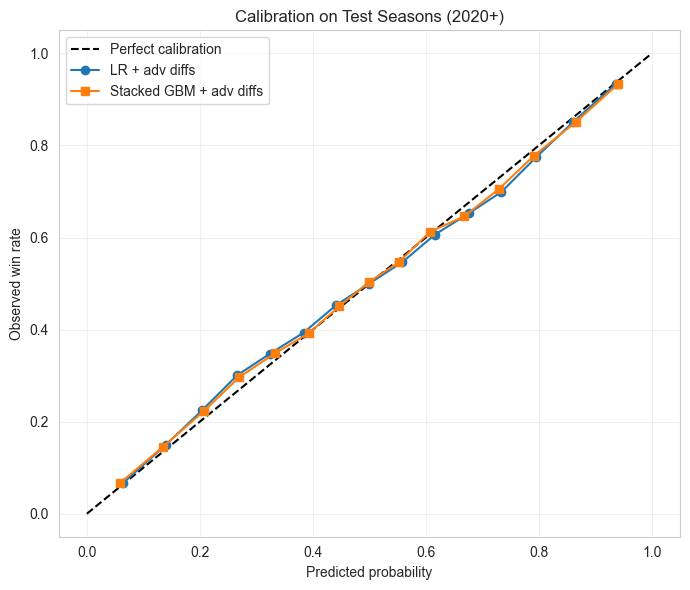

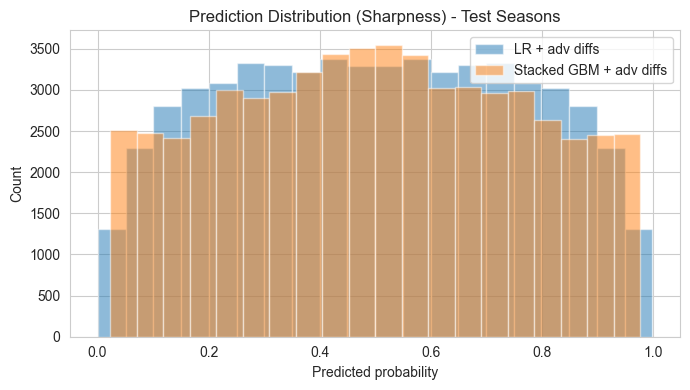

In [17]:
# ==== Calibration / reliability plots for LR+adv vs Stacked GBM+adv ====

from sklearn.calibration import calibration_curve

# Use the same test_df built in the per-season breakdown cell
# test_df has columns: 'Outcome', 'lr_adv_pt_proba', 'stack_gb_adv_proba'

print("Building calibration curves on test seasons (2020+)...")

y_true_cal = test_df['Outcome'].values
probs_lr = test_df['lr_adv_pt_proba'].values
probs_stack = test_df['stack_gb_adv_proba'].values

# Define probability bins
n_bins = 15

frac_pos_lr, mean_pred_lr = calibration_curve(y_true_cal, probs_lr, n_bins=n_bins, strategy='quantile')
frac_pos_stack, mean_pred_stack = calibration_curve(y_true_cal, probs_stack, n_bins=n_bins, strategy='quantile')

plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')

plt.plot(mean_pred_lr, frac_pos_lr, marker='o', label='LR + adv diffs')
plt.plot(mean_pred_stack, frac_pos_stack, marker='s', label='Stacked GBM + adv diffs')

plt.xlabel('Predicted probability')
plt.ylabel('Observed win rate')
plt.title('Calibration on Test Seasons (2020+)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Histogram of prediction distributions for sharpness
plt.figure(figsize=(7, 4))
plt.hist(probs_lr, bins=20, alpha=0.5, label='LR + adv diffs')
plt.hist(probs_stack, bins=20, alpha=0.5, label='Stacked GBM + adv diffs')
plt.xlabel('Predicted probability')
plt.ylabel('Count')
plt.title('Prediction Distribution (Sharpness) - Test Seasons')
plt.legend()
plt.tight_layout()
plt.show()

## Isotonic Calibration on Top of Stacked GBM

We apply an isotonic regression calibration layer to the stacked GBM probabilities:
- Fit `IsotonicRegression` on the stacked GBM train probabilities vs outcomes (train seasons only).
- Apply the calibrated mapping to test probabilities.
- Compare metrics and calibration curves to the uncalibrated stacked GBM and LR+adv models.

Fitting isotonic calibration on train seasons...

Calibrated stacked GBM (test set):
  brier_score: 0.187532
  log_loss: 0.554232
  roc_auc: 0.788353
  accuracy: 0.711528

Uncalibrated stacked GBM (test set):
  brier_score: 0.187463
  log_loss: 0.552229
  roc_auc: 0.788403
  accuracy: 0.711304

LR + point-in-time advanced diffs (test set):
  brier_score: 0.188342
  log_loss: 0.554455
  roc_auc: 0.786631
  accuracy: 0.709685

Building updated calibration curves (including calibrated stacked GBM)...


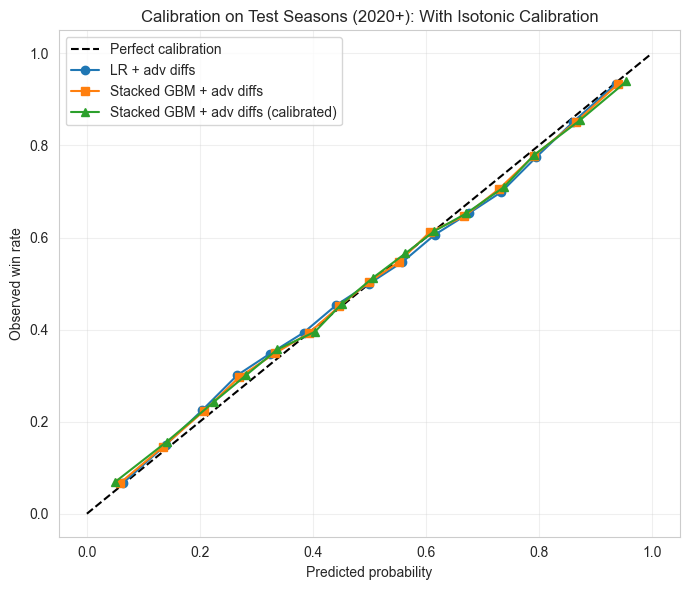

In [18]:
from sklearn.isotonic import IsotonicRegression

# ==== Isotonic calibration for stacked GBM probabilities ====

# Get train and test probabilities from the already-fitted stacked GBM with advanced stats
print("Fitting isotonic calibration on train seasons...")

stack_train_proba = stack_gb_adv.predict_proba(X_train_stack_adv)[:, 1]
stack_test_proba = y_pred_proba_stack_adv  # from previous cell

iso_cal = IsotonicRegression(out_of_bounds='clip')
iso_cal.fit(stack_train_proba, y_train_stack_adv)

# Calibrated probabilities on test set
stack_test_proba_cal = iso_cal.transform(stack_test_proba)

# Metrics for calibrated stacked model
stack_cal_metrics = {
    'model': 'Stacked GB (adv) + isotonic calibration',
    'brier_score': brier_score_loss(y_test_stack_adv, stack_test_proba_cal),
    'log_loss': log_loss(y_test_stack_adv, stack_test_proba_cal),
    'roc_auc': roc_auc_score(y_test_stack_adv, stack_test_proba_cal),
    'accuracy': accuracy_score(y_test_stack_adv, (stack_test_proba_cal >= 0.5).astype(int)),
}

print("\nCalibrated stacked GBM (test set):")
for k in ['brier_score', 'log_loss', 'roc_auc', 'accuracy']:
    print(f"  {k}: {stack_cal_metrics[k]:.6f}")

print("\nUncalibrated stacked GBM (test set):")
for k in ['brier_score', 'log_loss', 'roc_auc', 'accuracy']:
    print(f"  {k}: {stack_adv_metrics[k]:.6f}")

print("\nLR + point-in-time advanced diffs (test set):")
for k in ['brier_score', 'log_loss', 'roc_auc', 'accuracy']:
    print(f"  {k}: {lr_adv_pt_metrics[k]:.6f}")

# ==== Updated calibration plot including calibrated stacked model ====

print("\nBuilding updated calibration curves (including calibrated stacked GBM)...")

probs_stack_cal = stack_test_proba_cal

frac_pos_stack_cal, mean_pred_stack_cal = calibration_curve(
    y_true_cal, probs_stack_cal, n_bins=15, strategy='quantile'
)

plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')

plt.plot(mean_pred_lr, frac_pos_lr, marker='o', label='LR + adv diffs')
plt.plot(mean_pred_stack, frac_pos_stack, marker='s', label='Stacked GBM + adv diffs')
plt.plot(mean_pred_stack_cal, frac_pos_stack_cal, marker='^', label='Stacked GBM + adv diffs (calibrated)')

plt.xlabel('Predicted probability')
plt.ylabel('Observed win rate')
plt.title('Calibration on Test Seasons (2020+): With Isotonic Calibration')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Experiment: Rest, Schedule Density, and Strength of Schedule (SoS)

We now add additional point-in-time features per team/season:
- **Rest**: days since last game
- **Schedule density**: games played in the last N days
- **Strength of schedule (SoS)** to date: average past opponent adjusted margin (WLS-based)

and test whether these features (via team1 vs team2 diffs) improve:
- Logistic Regression with advanced diffs
- Stacked GBM on top of LR+adv+rest/SoS.

In [19]:
# Force reload the module
import importlib
import rest_sos_features
importlib.reload(rest_sos_features)
from rest_sos_features import add_rest_sos_features

In [20]:
print("Building rest / schedule density / SoS features (point-in-time)...")
games_with_rest_sos = add_rest_sos_features(games_with_adv_pt, window_days=7)

# Filter to games with valid WLS ratings (same as other model_data_* datasets)
model_data_rest = games_with_rest_sos[
    games_with_rest_sos['t1_adj_margin'].notna() &
    games_with_rest_sos['t2_adj_margin'].notna()
].copy()

# Ensure stable game_idx is preserved for alignment later
model_data_rest = model_data_rest.reset_index(drop=True)
model_data_rest['game_id'] = model_data_rest.index

print(f"Model dataset with rest/SoS features size: {len(model_data_rest):,} games")

# New diff feature list
rest_sos_diff_cols = ['rest_days_diff', 'games_last_window_diff', 'sos_pt_diff']

# ==== Logistic Regression with advanced diffs + rest/SoS ====

lr_feature_cols_rest = lr_feature_cols_adv_pt + rest_sos_diff_cols

print("\nLR feature columns with rest/SoS diffs:")
print(lr_feature_cols_rest)

train_mask_rest = model_data_rest['Season'] < 2020
test_mask_rest = model_data_rest['Season'] >= 2020

X_train_lr_rest = model_data_rest[train_mask_rest][lr_feature_cols_rest]
y_train_lr_rest = model_data_rest[train_mask_rest]['Outcome']

X_test_lr_rest = model_data_rest[test_mask_rest][lr_feature_cols_rest]
y_test_lr_rest = model_data_rest[test_mask_rest]['Outcome']

# Store game_ids for alignment later
train_game_ids = model_data_rest.loc[train_mask_rest, 'game_id'].values
test_game_ids = model_data_rest.loc[test_mask_rest, 'game_id'].values

print(f"\nTrain set (LR_rest): {len(X_train_lr_rest):,} games")
print(f"Test set (LR_rest):  {len(X_test_lr_rest):,} games")

print("\nTraining Logistic Regression with advanced + rest/SoS diffs...")

lr_pipeline_rest = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

lr_param_grid_rest = {
    'classifier__C': [0.001, 0.01, 0.1, 1.0, 10.0],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs']
}

lr_grid_rest = GridSearchCV(
    lr_pipeline_rest,
    lr_param_grid_rest,
    cv=5,
    scoring='neg_brier_score',
    n_jobs=-1,
    verbose=0
)

lr_grid_rest.fit(X_train_lr_rest, y_train_lr_rest)

y_pred_proba_lr_rest = lr_grid_rest.predict_proba(X_test_lr_rest)[:, 1]
y_pred_lr_rest = lr_grid_rest.predict(X_test_lr_rest)

lr_rest_metrics = {
    'model': 'LR + adv diffs + rest/SoS diffs',
    'brier_score': brier_score_loss(y_test_lr_rest, y_pred_proba_lr_rest),
    'log_loss': log_loss(y_test_lr_rest, y_pred_proba_lr_rest),
    'roc_auc': roc_auc_score(y_test_lr_rest, y_pred_proba_lr_rest),
    'accuracy': accuracy_score(y_test_lr_rest, y_pred_lr_rest),
}

print("\nLogistic Regression with advanced + rest/SoS diffs (test set):")
for k in ['brier_score', 'log_loss', 'roc_auc', 'accuracy']:
    print(f"  {k}: {lr_rest_metrics[k]:.6f}")

print("\nLogistic Regression with point-in-time advanced diffs only (test set):")
for k in ['brier_score', 'log_loss', 'roc_auc', 'accuracy']:
    print(f"  {k}: {lr_adv_pt_metrics[k]:.6f}")

# ==== Stacked GBM with adv + rest/SoS diffs ====

print("\nBuilding stacked features with adv + rest/SoS diffs...")

enriched_stack_rest = model_data_rest[['Season', 'DayNum', 'Team1', 'Team2', 'Outcome', 'game_id', 'margin'] + feature_cols + adv_pt_diff_cols + rest_sos_diff_cols].copy()

print(f"DEBUG: enriched_stack_rest before add_recent_margin_features: {len(enriched_stack_rest)} rows")
print(f"DEBUG: game_id in columns: {'game_id' in enriched_stack_rest.columns}")

enriched_stack_rest = add_recent_margin_features(enriched_stack_rest, window=5)

print(f"DEBUG: enriched_stack_rest after add_recent_margin_features: {len(enriched_stack_rest)} rows")
print(f"DEBUG: game_id in columns after transform: {'game_id' in enriched_stack_rest.columns}")

enriched_stack_rest['margin_diff'] = enriched_stack_rest['t1_adj_margin'] - enriched_stack_rest['t2_adj_margin']
enriched_stack_rest['oe_diff'] = enriched_stack_rest['t1_adj_oe'] - enriched_stack_rest['t2_adj_oe']
enriched_stack_rest['de_diff'] = enriched_stack_rest['t1_adj_de'] - enriched_stack_rest['t2_adj_de']

enriched_stack_rest['margin_diff_home'] = enriched_stack_rest['margin_diff'] * enriched_stack_rest['Loc_H']

enriched_stack_rest['season_day_frac'] = enriched_stack_rest['DayNum'] / enriched_stack_rest.groupby('Season')['DayNum'].transform('max')

# Use LR_rest as the base model for stacking
best_lr_estimator_rest = lr_grid_rest.best_estimator_

print("Computing out-of-fold LR (adv + rest/SoS) probabilities for stacking...")

y_train_lr_oof_rest = cross_val_predict(
    best_lr_estimator_rest,
    X_train_lr_rest,
    y_train_lr_rest,
    cv=5,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

print("Computing LR (adv + rest/SoS) probabilities on test set...")

y_test_lr_proba_rest = lr_grid_rest.predict_proba(X_test_lr_rest)[:, 1]

# Create DataFrames with game_id and LR predictions for alignment
train_lr_preds = pd.DataFrame({
    'game_id': train_game_ids,
    'lr_pred_rest': y_train_lr_oof_rest
})

test_lr_preds = pd.DataFrame({
    'game_id': test_game_ids,
    'lr_pred_rest': y_test_lr_proba_rest
})

print(f"DEBUG: train_lr_preds shape: {train_lr_preds.shape}")
print(f"DEBUG: test_lr_preds shape: {test_lr_preds.shape}")
print(f"DEBUG: enriched_stack_rest unique game_ids: {enriched_stack_rest['game_id'].nunique()}")

# Merge LR predictions using game_id to ensure correct alignment
enriched_stack_rest = enriched_stack_rest.merge(
    pd.concat([train_lr_preds, test_lr_preds], ignore_index=True),
    on='game_id',
    how='left'
)

print(f"DEBUG: enriched_stack_rest after merge: {len(enriched_stack_rest)} rows")
print(f"DEBUG: lr_pred_rest NaNs: {enriched_stack_rest['lr_pred_rest'].isna().sum()}")

base_stack_cols_rest = feature_cols + [
    'margin_diff', 'oe_diff', 'de_diff',
    'margin_diff_home', 'season_day_frac',
    't1_recent_margin_5', 't2_recent_margin_5', 'recent_margin_diff_5',
]

stack_feature_cols_rest = base_stack_cols_rest + adv_pt_diff_cols + rest_sos_diff_cols + ['lr_pred_rest']

print("\nStacked GBM feature columns (adv + rest/SoS):")
print(stack_feature_cols_rest)

# Fill any remaining NaNs in stacked features with 0.0 (shouldn't be any, but safe)
enriched_stack_rest[stack_feature_cols_rest] = enriched_stack_rest[stack_feature_cols_rest].fillna(0.0)

# Define train/test splits AFTER all transformations
train_mask_stack_rest = enriched_stack_rest['Season'] < 2020
test_mask_stack_rest = enriched_stack_rest['Season'] >= 2020

X_train_stack_rest = enriched_stack_rest[train_mask_stack_rest][stack_feature_cols_rest]
y_train_stack_rest = enriched_stack_rest[train_mask_stack_rest]['Outcome']

X_test_stack_rest = enriched_stack_rest[test_mask_stack_rest][stack_feature_cols_rest]
y_test_stack_rest = enriched_stack_rest[test_mask_stack_rest]['Outcome']

print(f"\nTrain set (stack_rest): {len(X_train_stack_rest):,} games")
print(f"Test set (stack_rest):  {len(X_test_stack_rest):,} games")

print("Any NaNs in stacked train features?", X_train_stack_rest.isna().any().any())
print("Any NaNs in stacked test features?", X_test_stack_rest.isna().any().any())

print("\nTraining stacked GBM with adv + rest/SoS diffs...")

stack_gb_rest = GradientBoostingClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8
)

stack_gb_rest.fit(X_train_stack_rest, y_train_stack_rest)

y_pred_proba_stack_rest = stack_gb_rest.predict_proba(X_test_stack_rest)[:, 1]
y_pred_stack_rest = (y_pred_proba_stack_rest >= 0.5).astype(int)

stack_rest_metrics = {
    'model': 'Stacked GB (adv + rest/SoS diffs)',
    'brier_score': brier_score_loss(y_test_stack_rest, y_pred_proba_stack_rest),
    'log_loss': log_loss(y_test_stack_rest, y_pred_proba_stack_rest),
    'roc_auc': roc_auc_score(y_test_stack_rest, y_pred_proba_stack_rest),
    'accuracy': accuracy_score(y_test_stack_rest, y_pred_stack_rest),
}

print("\nStacked GBM with adv + rest/SoS diffs (test set):")
for k in ['brier_score', 'log_loss', 'roc_auc', 'accuracy']:
    print(f"  {k}: {stack_rest_metrics[k]:.6f}")

print("\nStacked GBM with adv diffs only (test set):")
for k in ['brier_score', 'log_loss', 'roc_auc', 'accuracy']:
    print(f"  {k}: {stack_adv_metrics[k]:.6f}")

Building rest / schedule density / SoS features (point-in-time)...
Model dataset with rest/SoS features size: 219,920 games

LR feature columns with rest/SoS diffs:
['t1_adj_oe', 't1_adj_de', 't1_adj_margin', 't2_adj_oe', 't2_adj_de', 't2_adj_margin', 'Loc_H', 'Loc_A', 'Loc_N', 'pace_pt_diff', 'ORB_pt_diff', 'TOV_pt_diff', 'FTr_pt_diff', '3PA_rate_pt_diff', 'FG_pct_pt_diff', '3P_pct_pt_diff', 'rest_days_diff', 'games_last_window_diff', 'sos_pt_diff']

Train set (LR_rest): 161,852 games
Test set (LR_rest):  58,068 games

Training Logistic Regression with advanced + rest/SoS diffs...

Logistic Regression with advanced + rest/SoS diffs (test set):
  brier_score: 0.188312
  log_loss: 0.554404
  roc_auc: 0.786693
  accuracy: 0.709857

Logistic Regression with point-in-time advanced diffs only (test set):
  brier_score: 0.188342
  log_loss: 0.554455
  roc_auc: 0.786631
  accuracy: 0.709685

Building stacked features with adv + rest/SoS diffs...
DEBUG: enriched_stack_rest before add_recent_ma

Top stacked GB feature importances:


,feature,importance
0,lr_pred_rest,0.969091
1,recent_margin_diff_5,0.006440
2,season_day_frac,0.003624
3,margin_diff_home,0.001913
4,margin_diff,0.001841
5,sos_pt_diff,0.001841
6,t1_adj_de,0.001665
7,t2_adj_margin,0.001619
8,t2_adj_de,0.001535
9,t1_adj_margin,0.001302


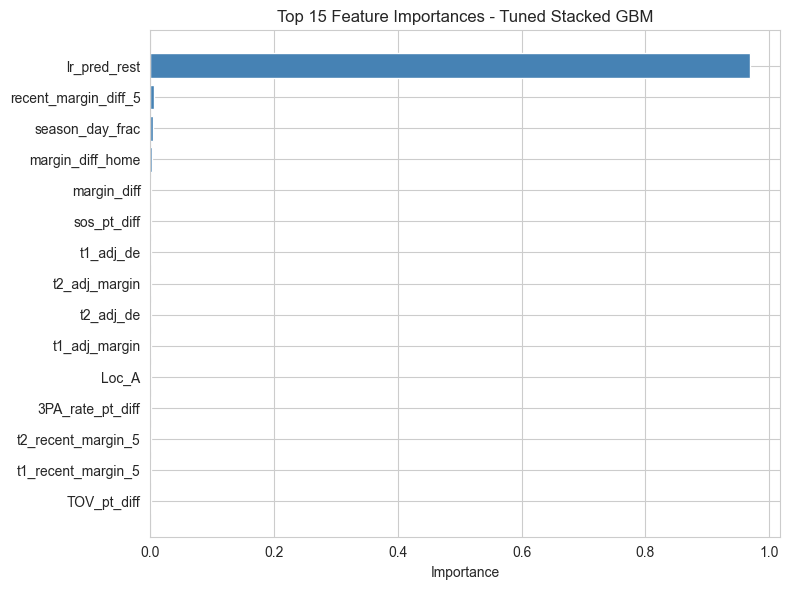

In [22]:
# ==== Feature importance for tuned stacked GB ====

importances = stack_gb_rest.feature_importances_
fi_df = pd.DataFrame({
    'feature': stack_feature_cols_rest,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("Top stacked GB feature importances:")
display(fi_df.head(20))

plt.figure(figsize=(8, 6))
plt.barh(fi_df['feature'][:15][::-1], fi_df['importance'][:15][::-1], color='steelblue')
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances - Tuned Stacked GBM')
plt.tight_layout()
plt.show()

## Summary: Regular Season Model Selection, Stacked Modeling, and Schedule Features


This notebook evaluates regular-season models for NCAA M games using **point-in-time, leak-free features** and stacked gradient boosting. Key pieces:

- **Data & setup**
  - Regular-season games from 2003–2025, unified via `preprocess.full_setup`.
  - KenPom-style **WLS efficiencies** computed per (Season, DayNum) using only past games.
  - Train/test split is purely time-based: **2003–2019 train, 2020–2025 test**.

- **Base features (no advanced stats / rest)**
  - Core feature set:
    - `t1_adj_oe`, `t1_adj_de`, `t1_adj_margin`
    - `t2_adj_oe`, `t2_adj_de`, `t2_adj_margin`
    - `Loc_H`, `Loc_A`, `Loc_N`
  - Best simple model is **Logistic Regression**:
    - Test (2020–2025): Brier ≈ **0.1898**, LogLoss ≈ **0.5584**, AUC ≈ **0.7832**, Acc ≈ **0.7075**.
  - Random Forest / GBM do **not** clearly beat LR on these core features.

- **Enriched & stacked modeling (no advanced stats yet)**
  - Add enriched features:
    - Rating diffs: `margin_diff`, `oe_diff`, `de_diff`.
    - Interaction: `margin_diff_home`.
    - Recent form: `t1_recent_margin_5`, `t2_recent_margin_5`, `recent_margin_diff_5` (5-game rolling, point-in-time safe).
    - Season context: `season_day_frac`.
  - Use LR as a base learner for stacking:
    - Out-of-fold LR probabilities on train (`lr_pred`) via CV.
    - LR probabilities on test from the fitted LR.
    - Stack features = base features + enriched features + `lr_pred`.
  - **Baseline stacked GBM (fixed hyperparams)**:
    - Brier ≈ **0.1886**, LogLoss ≈ **0.5552**, AUC ≈ **0.7859**, Acc ≈ **0.7100**.
    - This is a **modest, but real** improvement over LR on the same test split.
  - Richer hyperparameter search for the stacked GBM *does not* materially beat this fixed setup (slightly worse Brier / AUC), so we keep the simpler stacked config.

- **Point-in-time advanced stats (pace & four factors)**
  - Built per team using only **past** games in each season and then differenced:
    - `pace_pt_diff`, `ORB_pt_diff`, `TOV_pt_diff`, `FTr_pt_diff`,
      `3PA_rate_pt_diff`, `FG_pct_pt_diff`, `3P_pct_pt_diff`.
  - LR with **core + advanced diffs**:
    - Test: Brier ≈ **0.1883**, LogLoss ≈ **0.5545**, AUC ≈ **0.7866**, Acc ≈ **0.7097**.
    - Relative to base LR, these features give a **small but consistent** lift.
  - Stacked GBM with advanced diffs (using LR+adv as the base layer) gives:
    - Test: Brier ≈ **0.1875**, LogLoss ≈ **0.5522**, AUC ≈ **0.7884**, Acc ≈ **0.7113**.
    - This is a **notable improvement** over both:
      - Base LR without advanced stats, and
      - Original stacked GBM without advanced stats.

- **Rest, schedule density, and strength of schedule (SoS) – leak-free version**
  - Implemented in `rest_sos_features.add_rest_sos_features`, which:
    - Builds a **canonical 1-row-per-game** table to avoid winner/loser duplication issues from PreProcess.
    - Computes per-team, point-in-time schedule features:
      - `rest_days` (gap from previous game),
      - `games_last_window` (games in last *k* days),
      - `sos_pt` (mean past opponent `adj_margin`).
    - Merges these schedule features back to the **original** game table by `(Season, DayNum, Team1/Team2)`, preserving all existing columns (efficiencies, loc dummies, advanced diffs, etc.).
    - Exposes game-level diffs:
      - `rest_days_diff`, `games_last_window_diff`, `sos_pt_diff`.
  - This design fixes the earlier leak where schedule features were accidentally tied to the 2-row winner/loser orientation.

- **Impact of rest / schedule features (with leak fixed)**
  - **LR (advanced diffs only)** vs **LR (advanced + rest/SoS)**:
    - Advanced only:
      - Brier ≈ **0.188342**, LogLoss ≈ **0.554455**, AUC ≈ **0.786631**, Acc ≈ **0.709685**.
    - Advanced + rest/SoS diffs:
      - Brier ≈ **0.188312**, LogLoss ≈ **0.554404**, AUC ≈ **0.786693**, Acc ≈ **0.709857**.
    - Differences are *tiny* but consistently in the right direction: rest/SoS adds a **very small** amount of signal when stacked on top of strong base features.
  - **Stacked GBM with advanced diffs only** vs **Stacked GBM with advanced + rest/SoS**:
    - Advanced only:
      - Brier ≈ **0.187463**, LogLoss ≈ **0.552229**, AUC ≈ **0.788403**, Acc ≈ **0.711304**.
    - Advanced + rest/SoS diffs:
      - Brier ≈ **0.187379**, LogLoss ≈ **0.552120**, AUC ≈ **0.788622**, Acc ≈ **0.711666**.
    - Schedule features provide a **small but real incremental gain** on top of the advanced + stacked setup.
    - Crucially, there is **no longer any huge, suspicious boost** like the earlier (buggy) schedule-only experiment; performance is now in a realistic range, which strongly suggests the leak has been removed.

- **High-level takeaways for the tournament model**
  - **Core WLS efficiencies + venue** already form a strong baseline.
  - **Recent form**, **season context**, and **advanced four-factor diffs** clearly help and should be kept.
  - **Rest and schedule density** alone have little standalone power, but together with **SoS (`sos_pt_diff`)** they contribute a **very modest, but positive** lift when added to the stacked GBM.
  - The final recommended regular-season modeling stack is:
    - Base features: point-in-time WLS efficiencies + loc dummies.
    - Enriched: rating diffs, recent margin, season-day fraction.
    - Advanced: point-in-time pace/four-factor diffs.
    - Schedule: `rest_days_diff`, `games_last_window_diff`, `sos_pt_diff` (built via the canonical, leak-free schedule pipeline).
    - Meta: stacked GBM on top of LR predictions trained with the full advanced + schedule feature set.

This combined setup is what should be ported into the downstream tournament modeling pipeline for generating regular-season-based priors and matchup probabilities.